# A quick introduction

The intention of Textplumber is to make it easy to extract features from text data as part of a Sci-kit learn pipeline. It allows you to extract different kinds of features extracted from text, which you can combine as needed. Here's an example ...

In [ ]:
import os
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif, chi2
from sklearn.pipeline import FeatureUnion
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

from textplumber.core import *
from textplumber.clean import *
from textplumber.preprocess import *
from textplumber.tokens import *
from textplumber.pos import *
from textplumber.embeddings import *
from textplumber.report import *
from textplumber.store import *
from textplumber.lexicons import *
from textplumber.textstats import *

First, let's load some data from the [AuthorMix dataset](https://huggingface.co/datasets/hallisky/AuthorMix). This dataset includes samples of fiction ('author'), speeches ('speech') and blog posts ('blog').

In [ ]:
X_train, y_train, X_test, y_test, target_classes, target_names = get_example_data(target_labels = ['blog', 'speech'])

Next, define an SQLite database to store features so we can avoid recomputing them every time we run the pipeline via `TextFeatureStore`. A feature store is required for most of the components in this package.

In [ ]:
feature_store = TextFeatureStore('basic-introduction-store.sqlite')

In the example pipeline, the texts are cleaned with `TextCleaner`, then preprocessed using `SpacyPreprocessor`, and then features based on token counts are extracted using `TokensVectorizer`.

Below we train a model and evaluate it on the test set. For a nicely labelled confusion matrix use `plot_confusion_matrix`.

In [ ]:
pipeline = Pipeline([
    ('cleaner', TextCleaner(strip_whitespace=True)),
    ('preprocessor', SpacyPreprocessor(feature_store=feature_store, pos_tagset = 'detailed')),
    ('tokens', TokensVectorizer(feature_store=feature_store, max_features=200)),
    ('classifier', LogisticRegression(max_iter=5000, random_state=4)),
], verbose=True)

display(pipeline)

Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object>,
                                   pos_tagset='detailed')),
                ('tokens',
                 TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore object>,
                                  max_features=200)),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=4))],
         verbose=True)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

[Pipeline] ........... (step 1 of 4) Processing cleaner, total=   0.0s
[Pipeline] ...... (step 2 of 4) Processing preprocessor, total=  31.8s
[Pipeline] ............ (step 3 of 4) Processing tokens, total=   1.6s
[Pipeline] ........ (step 4 of 4) Processing classifier, total=   0.2s


              precision    recall  f1-score   support

        blog      0.931     0.935     0.933       981
      speech      0.913     0.908     0.911       740

    accuracy                          0.923      1721
   macro avg      0.922     0.921     0.922      1721
weighted avg      0.923     0.923     0.923      1721



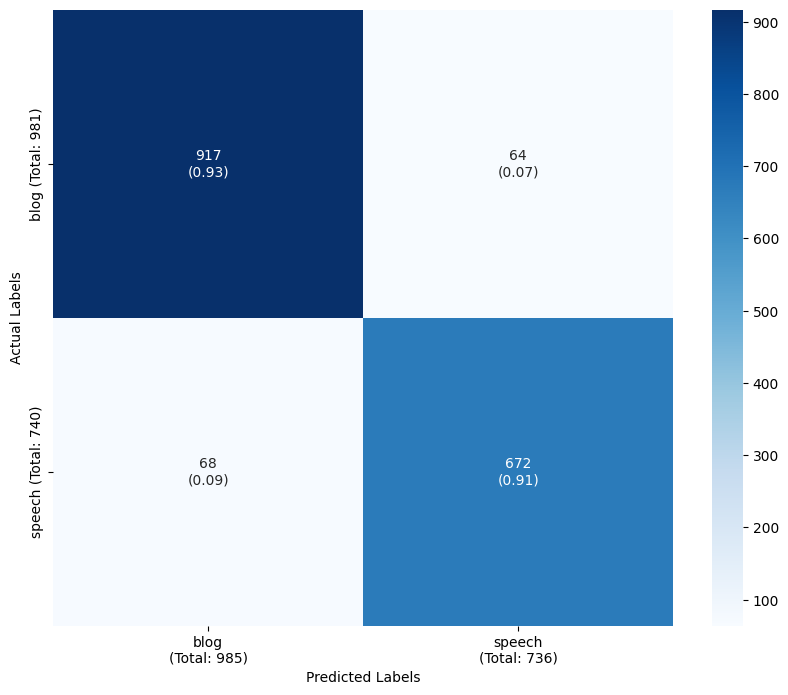

In [ ]:
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

Let's create a more complex pipeline with different kinds of features.

This pipeline combines tf-idf weighted token features, features based on bigrams of part-of-speech tags, and embeddings. The pipeline applies feature selection using standard Scikit-learn components.

In [ ]:
pipeline = Pipeline([
	('cleaner', TextCleaner(strip_whitespace=True)),
	('preprocessor', SpacyPreprocessor(feature_store=feature_store, pos_tagset = 'detailed')),
	('features', FeatureUnion([

		('tokens', Pipeline([
			('token_vectors',  TokensVectorizer(feature_store=feature_store, vectorizer_type='tfidf', max_features=200)),
			('selector', SelectKBest(score_func=chi2, k=200)),            
			], verbose=True)
		),

		('pos', Pipeline([
			('pos_vectors',  POSVectorizer(feature_store=feature_store, ngram_range = (2, 2))),
			('selector', SelectKBest(score_func=mutual_info_classif, k=120)),
			], verbose=True)
		),

		('textstats', 
			Pipeline([
				('textstats_vectors', TextstatsTransformer(feature_store=feature_store)), 
				('selector', SelectKBest(score_func=mutual_info_classif, k=6)),
				], verbose = True)),

		('embeddings', Model2VecEmbedder(feature_store=feature_store)),
	], verbose=True)),
	('scaler', StandardScaler(with_mean=False)),
	('classifier', LogisticRegression(max_iter=5000, random_state=4)),
], verbose=True)

display(pipeline)

Pipeline(steps=[('cleaner', TextCleaner(strip_whitespace=True)),
                ('preprocessor',
                 SpacyPreprocessor(feature_store=<textplumber.store.TextFeatureStore object>,
                                   pos_tagset='detailed')),
                ('features',
                 FeatureUnion(transformer_list=[('tokens',
                                                 Pipeline(steps=[('token_vectors',
                                                                  TokensVectorizer(feature_store=<textplumber.store.TextFeatureStore obje...
                                                                  TextstatsTransformer(feature_store=<textplumber.store.TextFeatureStore object>)),
                                                                 ('selector',
                                                                  SelectKBest(k=6,
                                                                              score_func=<function mutual_info_classif>))],
                                                          verbose=True)),
                                                ('embeddings',
                                                 Model2VecEmbedder(feature_store=<textplumber.store.TextFeatureStore object>))],
                              verbose=True)),
                ('scaler', StandardScaler(with_mean=False)),
                ('classifier',
                 LogisticRegression(max_iter=5000, random_state=4))],
         verbose=True)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

[Pipeline] ........... (step 1 of 5) Processing cleaner, total=   0.0s
[Pipeline] ...... (step 2 of 5) Processing preprocessor, total=   0.4s
[Pipeline] ..... (step 1 of 2) Processing token_vectors, total=   0.9s
[Pipeline] .......... (step 2 of 2) Processing selector, total=   0.0s
[FeatureUnion] ........ (step 1 of 4) Processing tokens, total=   0.9s
[Pipeline] ....... (step 1 of 2) Processing pos_vectors, total=   1.0s
[Pipeline] .......... (step 2 of 2) Processing selector, total=   1.8s
[FeatureUnion] ........... (step 2 of 4) Processing pos, total=   2.7s
[Pipeline] . (step 1 of 2) Processing textstats_vectors, total=   0.5s
[Pipeline] .......... (step 2 of 2) Processing selector, total=   0.3s
[FeatureUnion] ..... (step 3 of 4) Processing textstats, total=   0.8s
[FeatureUnion] .... (step 4 of 4) Processing embeddings, total=   0.8s
[Pipeline] .......... (step 3 of 5) Processing features, total=   5.3s
[Pipeline] ............ (step 4 of 5) Processing scaler, total=   0.0s
[Pipel

              precision    recall  f1-score   support

        blog      0.954     0.970     0.962       981
      speech      0.960     0.938     0.949       740

    accuracy                          0.956      1721
   macro avg      0.957     0.954     0.955      1721
weighted avg      0.956     0.956     0.956      1721



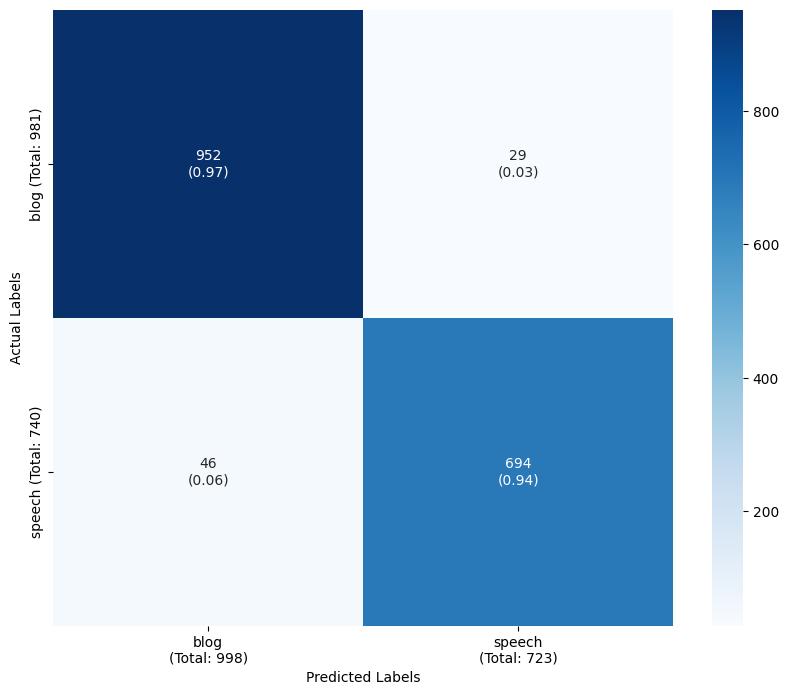

In [ ]:
print(classification_report(y_test, y_pred, labels = target_classes, target_names = target_names, digits=3))
plot_confusion_matrix(y_test, y_pred, target_classes, target_names)

Notice that the preprocessor step is significantly faster, as we are getting the features from the feature store. 

The pipeline components allow you to extract a variety of feature types. Look at the [example notebook](example.ipynb) for a more extensive example.

In [ ]:
# cleaning up
os.remove('basic-introduction-store.sqlite')